In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import os
import sys
from dataclasses import dataclass
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from models import StftArgument
import stft
from stft import *

In [2]:
argument = StftArgument()
stft = STFT(argument)
sound = SoundData()

In [3]:
tmax = 2
nu = 441.8 #Hz
A = 1
trange = stft.range(0,tmax)
data = A*np.sin(2*np.pi*nu*trange)
stft(data)

In [4]:
stft.W_vector.shape, stft.N_T

((4410,), 2205)

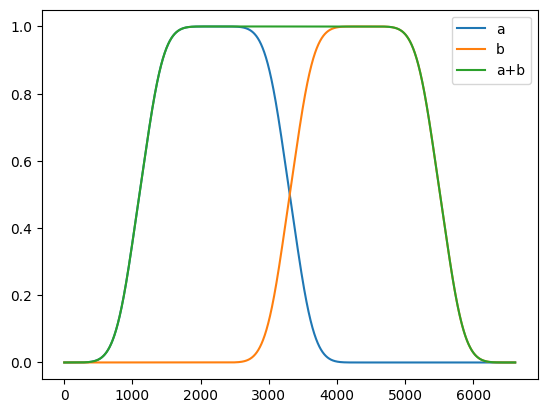

In [5]:
NT = stft.N_T
a = np.concatenate([stft.W_vector, np.zeros(NT)])
b = np.concatenate([np.zeros(NT), stft.W_vector])
plt.plot(a, label='a')
plt.plot(b, label='b')
plt.plot(a+b, label='a+b')
plt.legend()

In [134]:
@dataclass
class Note:
    length: float
    note: str
    pitch: int = 0
    A: float = 1.0
    fade: float = 0.1

    @staticmethod
    def from_string(s):
        parts = s.split(':')
        note = parts[0]
        length = float(parts[1])
        pitch_str = parts[2] if len(parts) > 2 else 0
        if pitch_str == '':
            pitch = 0
        else:
            pitch = int(pitch_str)
        A = float(parts[3]) if len(parts) > 3 else 1.0
        fade = float(parts[4]) if len(parts) > 4 else 0.1
        return Note(length, note, pitch, A, fade)

class Synthetizer:
    def __init__(self, time_unit=1.0, window=None):
        if window is None:
            self.window = self.window
        else:
            self.window = window
        self.time_unit = time_unit
        self.sample_rate = 44100
        self.dt = 1/self.sample_rate
        self.A4 = 440 #Hz
        ratio = 2 ** (1/12)
        self.notes = { 
            'C' : self.A4 * ratio**(-9),
            'C#': self.A4 * ratio**(-8),
            'D' : self.A4 * ratio**(-7),
            'D#': self.A4 * ratio**(-6),
            'E' : self.A4 * ratio**(-5),
            'F' : self.A4 * ratio**(-4),
            'F#': self.A4 * ratio**(-3),
            'G' : self.A4 * ratio**(-2),
            'G#': self.A4 * ratio**(-1),
            'A' : self.A4,
            'A#': self.A4 * ratio,
            'B' : self.A4 * ratio**2,
            'c' : self.A4 * ratio**3,
            'c#': self.A4 * ratio**4,
            'd' : self.A4 * ratio**5,
            'd#': self.A4 * ratio**6,
            'e' : self.A4 * ratio**7,
            'f' : self.A4 * ratio**8,
            'f#': self.A4 * ratio**9,
            'g' : self.A4 * ratio**10,
            'g#': self.A4 * ratio**11,
            'a' : self.A4 * ratio**12,
            'a#': self.A4 * ratio**13,
            'b' : self.A4 * ratio**14,
            '' : 0
        }
        self.data = {}
    
    def window(self, dt):
        f = lambda x: (1 + np.sin(np.pi*(x+0.5)))/2
        t = np.arange(-1,1,dt)
        return f(t)

    def soft_sound(self, note:Note|str):
        if isinstance(note, str):
            note = Note.from_string(note)
        nu = self.notes[note.note]*(2**note.pitch)
        if nu == 0:
            return np.zeros(int(self.time_unit * float(note.length) / self.dt)), 0
        compensated_amplitude = note.A * self.A4/nu
        trange = np.arange(0, self.time_unit * float(note.length), self.dt)
        data = compensated_amplitude * np.sin(2 * np.pi * nu * trange)
        dt_window = self.dt * 2/note.fade
        window_vector = self.window(dt_window)
        wlength = window_vector.shape[0]
        data_length = data.shape[0]
        length_to_add = data_length - wlength
        if length_to_add < 0:
            raise ValueError('Note is too short for the fade time')
            #mask = np.concatenate([window_vector[:data_length//2], window_vector[wlength//2:]])
        else:
            mask = np.concatenate([window_vector[:wlength//2], np.ones(length_to_add), window_vector[wlength//2:]])
        return mask*data, wlength//2
    
    def clear_channel(self, channel='default'):
        self.data[channel] = np.array([])

    def add_sound(self, note:Note|str, channel='default'):
        if isinstance(note, str):
            note = Note.from_string(note)
        addon,NT = self.soft_sound(note)
        d1 = np.concatenate([self.data[channel], np.zeros(addon.shape[0]-NT)])
        if self.data[channel].shape[0] > NT:
            d2 = np.concatenate([np.zeros(self.data[channel].shape[0]-NT), addon])
            self.data[channel] = d1 + d2
        else:
            self.data[channel] = addon

    def combine_channels(self, channel1, channel2, new_channel='combined'):
        d1 = self.data[channel1]
        d2 = self.data[channel2]
        if d1.shape[0] > d2.shape[0]:
            d2 = np.concatenate([d2, np.zeros(d1.shape[0]-d2.shape[0])])
        else:
            d1 = np.concatenate([d1, np.zeros(d2.shape[0]-d1.shape[0])])
        self.data[new_channel] = d1 + d2

    def play(self, channel='combined'):
        if channel not in self.data:
            channel = 'default'
        sound = SoundData()
        sound.set(self.data[channel])
        sound.play()

    def save(self, filename, channels=['default']):
        data = np.stack([self.data[channel] for channel in channels], axis=1)
        sf.write(filename, data, self.sample_rate)


In [135]:
syn = Synthetizer()

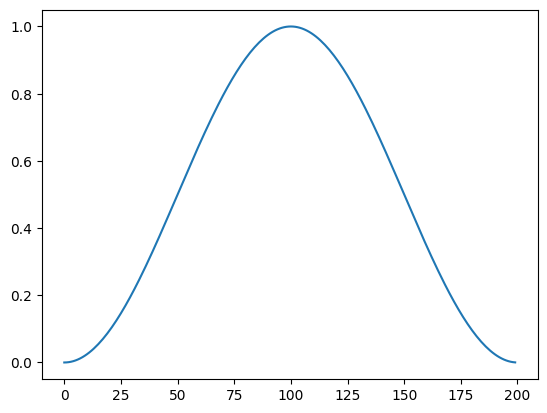

In [136]:
plt.plot(syn.window(0.01))

In [158]:
syn.clear_channel()
syn.time_unit = 0.4
song = 'C:1,E:1,C:1,E:1,G:2,G:1,:1,C:1,E:1,C:1,E:1,G:2,G:1,:1,c:1,B:1,A:1,G:1,F:2,A:2,G:1,F:1,E:1,D:1,C:2,C:2'
for note in song.split(','):
    syn.add_sound(note)


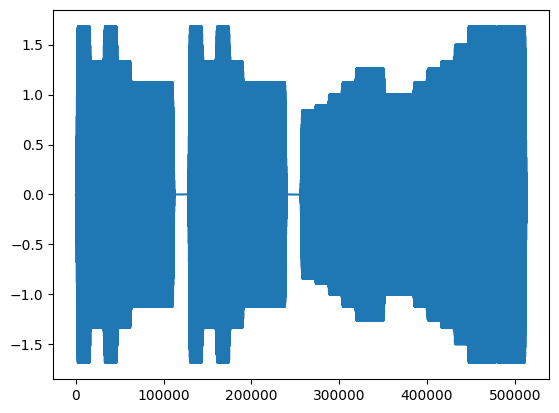

In [159]:
plt.plot(syn.data['default'])

In [154]:
syn.play('default')

In [160]:
syn.clear_channel('ch1')
song = 'G:1,G:1,G:1,G:1,G:1,G:1,D:2,G:2'
for note in song.split(','):
    syn.add_sound(note, channel='ch1')
syn.clear_channel('ch2')
song = 'B:1::0.2,B:1::0.2,B:1::0.2,B:1::0.2,B:1::0.2,B:1::0.2,G:2::0.2,B:2::0.2'
for note in song.split(','):
    syn.add_sound(note, channel='ch2')
syn.combine_channels('ch1', 'ch2')

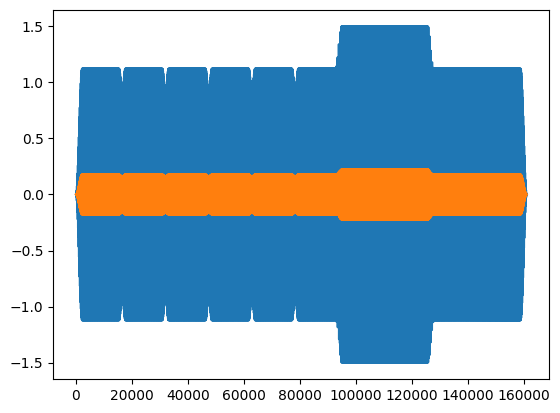

In [161]:
plt.plot(syn.data['ch1'])
plt.plot(syn.data['ch2'])


In [162]:
syn.play('combined')

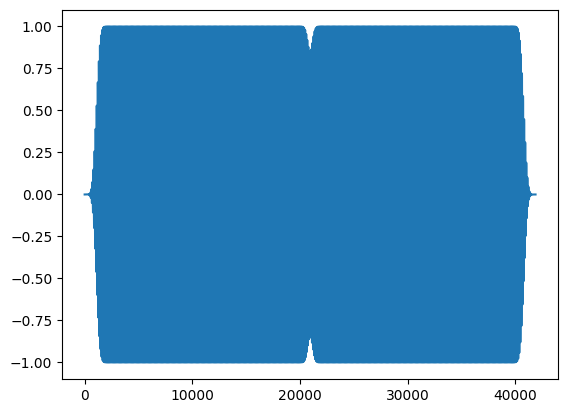

In [57]:
def soft_sound(frequency, length, window):
    tmax = length
    nu = frequency
    A = 1
    trange = stft.range(0, tmax)
    data = A * np.sin(2 * np.pi * nu * trange)
    length_to_add = data.shape[0] - window.shape[0]
    mask = np.concatenate([window[:stft.N_T], np.ones(length_to_add), window[stft.N_T:]])
    return mask*data

nu = 441.8 #Hz
tsound = 0.5 #sec
window = stft.W_vector
#window = np.ones(stft.N_T*2)

def add_to_data(data, addon, window):
    NT = window.shape[0]//2
    if addon.shape[0] < NT:
        raise ValueError('Addon is too short')
    d1 = np.concatenate([data, np.zeros(addon.shape[0]-NT)])
    if data.shape[0] > NT:
        d2 = np.concatenate([np.zeros(data.shape[0]-NT), addon])
        return d1 + d2
    else:
        return addon

def add_sound(data, frequency, length, window):
    addon = soft_sound(frequency, length, window)
    return add_to_data(data, addon, window)

data = np.array([])
data = add_sound(data, nu, tsound, window)
data = add_sound(data, nu, tsound, window)
plt.plot(data)
plt.show()


In [58]:
sound.set(data)
sound.play()

(<Figure size 640x480 with 1 Axes>, <Axes: >)

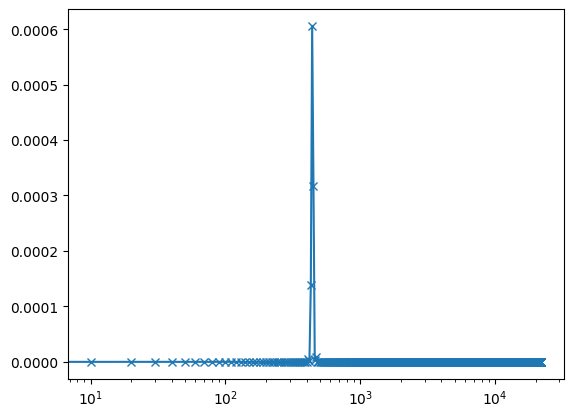

In [52]:
stft.plot_spectrum(0, line='x-')

In [ ]:
stft.plot